# CaliforniaHousing

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error

import numpy as np
import matplotlib.pyplot as plt

###Definition

In [ ]:
housing = fetch_california_housing()

###train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    housing.data,
    housing.target,
    test_size=0.2,
)

###desc

     برای مثال  :

     کل داده : 9 8 7 6 5 4 3 2 1      

     │
     ├── X_train , y_train   ← برای آموزش
     └── X_test , y_test       ← برای تست

     X_train = 1 2 3 4 5 6 7 8
     X_test   = 9 10

###train_test_split

In [ ]:
X_train1, X_val, y_train1, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
)

###desc

      X_train = 1 2 3 4 5 6 7 8

     X_train
     │
     ├── X_train1
     └── X_val
   
     X_train  = 1 2 3 4 5 6
     X_val    = 7 8

      کل داده
     │
     ├── Train
     ├── Validation
     └── Test

کل داده: 20640

         train                  test
         80%                    20%
          |                      |
          ↓                      ↓
        X_train                 X_test
        16512×8                 4128×8

        y_train                 y_test
        16512                  4128


        X_train (16512)
              |
              |
              ↓
        ----------------
       |                |
     Train1          Validation
      80%               20%
       |                |
       ↓                ↓
     13209            3303

###print

In [ ]:
print('X_train : ',X_train.shape),
print('X_test  : ',X_test.shape),
print('y_train : ',y_train.shape),
print('y_test  : ',y_test.shape),

print('X_train1 : ',X_train1.shape),
print('X_val    : ',X_val.shape),
print('y_train1 : ',y_train1.shape),
print('y_val    : ',y_val.shape)

###desc

      نکته مهم: فقط روی داده‌های ترین باید   
      fit
      انجام شود تا اطلاعاتی از آینده
     (داده‌های Validation و Test)
      به مدل نشت نکند  


###StandardScaler

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train1)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [ ]:
X_train_scaled_1, X_train_scaled_2 = X_train_scaled[:, -4:], X_train_scaled[:, :-4]
X_val_scaled_1, X_val_scaled_2 = X_val_scaled[:, -4:], X_val_scaled[:, :-4]
X_test_scaled_1, X_test_scaled_2 = X_test_scaled[:, -4:], X_test_scaled[:, :-4]


###desc

         
             برای اینکه ما دوم مقدار ورودی داشته باشیم و رودی هارا میشکنیم  
             [:,-x:]
             یعنی ":" همه سطر هارا بگیر
             یعنی "-x:" از اخر  
             x
             تا مقدار بردار
             [:,:-x]
             یعنی ":" همه سطر هارا بگیر
             یعنی ":-x"
             تعداد ستون -x =  y
             y
             تا مقدار از اول بردار


             برای مثال
             X_train1 :  (13209, 8) =>  یعتی 8 ستون و 13209 تا سطر

               ستون ها:  [a,   b,   c,   d,   e,   f,   g,   h]  

                X_train1_s[:,-5:]  : d,   e,   f,   g,   h (5تای اخری )

                X_train1_s[:,:-5]  : a,   b,   c  ( (8-5 = 3) 3 تای اولی )



###len

In [ ]:
len(np.unique(y_train))

###EarlyStopping

In [ ]:
early_stopping=keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

## آموزش مدل با یک ورودی

####Model

In [ ]:
model=keras.models.Sequential(
    [
    keras.layers.Dense(128,activation="relu" ,input_shape=(8,)),
    keras.layers.Dense(64,activation="relu"),
    keras.layers.Dense(1)
   ]
    )

In [ ]:
model.summary()

In [ ]:
weight,bias= model.layers[2].get_weights()
print(weight.shape)
print(bias.shape)

####compile

In [ ]:
model.compile(
    optimizer="sgd",
    loss="mse",
    metrics=["mae"]
)

####fit

In [ ]:
history = model.fit(
    X_train_scaled,
    y_train1,
    epochs=30,
    batch_size=32,
    validation_data=(X_val_scaled, y_val),
    callbacks=[early_stopping]
)

##trainingPerformance

####نمودار آموزش

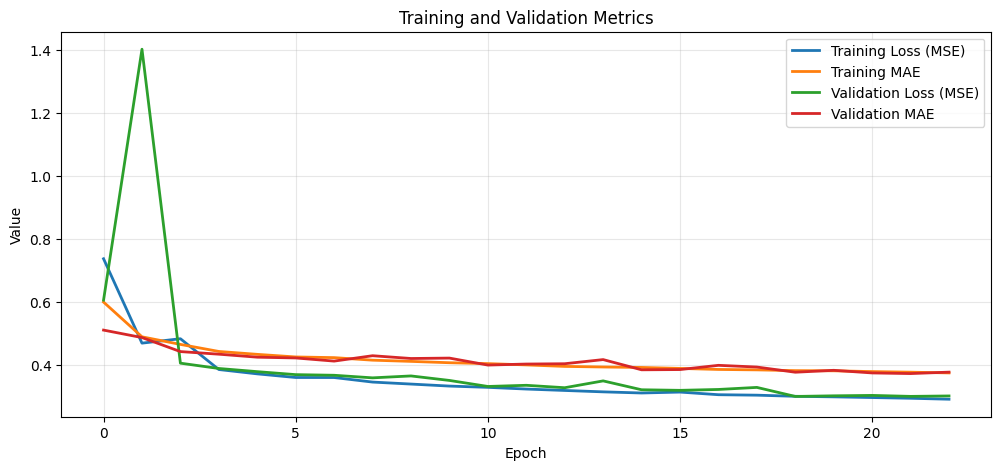

In [65]:

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(history.history['loss'], label='Training Loss (MSE)', linewidth=2)
ax.plot(history.history['mae'], label='Training MAE', linewidth=2)
ax.plot(history.history['val_loss'], label='Validation Loss (MSE)', linewidth=2)
ax.plot(history.history['val_mae'], label='Validation MAE', linewidth=2)

ax.set_xlabel('Epoch')
ax.set_ylabel('Value')
ax.set_title('Training and Validation Metrics')
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()

### محاسبه درصد یادگیری

In [66]:
def evaluate_model(model, X_test_scaled, y_test):
    """ارزیابی نهایی مدل روی داده تست"""
    y_pred = model.predict(X_test_scaled)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    print("=" * 50)
    print("📊 Model Performance")  # عملکرد مدل
    print("=" * 50)
    print(f"R2 Score: {r2:.4f}")  # ضریب تعیین
    print(f"Learning Percentage: {r2 * 100:.2f}%")  # درصد یادگیری
    print(f"MAE: {mae:.4f}")  # میانگین خطای مطلق
    print("=" * 50)

    if r2 >= 0.7:
        print("✅ Excellent Model!")  # مدل عالی است
    elif r2 >= 0.5:
        print("👍 Good Model!")  # مدل خوب است
    elif r2 >= 0.3:
        print("⚠️ Average Model!")  # مدل متوسط است
    else:
        print("❌ Poor Model!")  # مدل ضعیف است

# استفاده:
evaluate_model(model, X_test_scaled, y_test)

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
📊 Model Performance
R2 Score: 0.7595
Learning Percentage: 75.95%
MAE: 0.3853
✅ Excellent Model!


###تحلیل خودکار نمودارهای آموزش

In [67]:
def analyze_training(history):

    train_loss = history.history['loss'][-1]
    val_loss = history.history['val_loss'][-1]
    train_mae = history.history['mae'][-1]
    val_mae = history.history['val_mae'][-1]

    loss_change = (history.history['loss'][0] - train_loss) / history.history['loss'][0] * 100
    val_loss_change = (history.history['val_loss'][0] - val_loss) / history.history['val_loss'][0] * 100

    print("=" * 60)
    print("📊 تحلیل عملکرد مدل:")
    print("-" * 60)
    print(f"کاهش Training Loss:  {loss_change:.1f}%")
    print(f"کاهش Validation Loss: {val_loss_change:.1f}%")
    print(f"Training Loss:     {train_loss:.4f}")
    print(f"Validation Loss:   {val_loss:.4f}")
    print(f"تفاوت Loss:        {abs(train_loss - val_loss):.4f}")
    print("-" * 60)

    if abs(train_loss - val_loss) < 0.05 and loss_change > 50:
        print("✅ عالی! مدل به خوبی یاد گرفته و Overfitting ندارد.")
    elif abs(train_loss - val_loss) > 0.1:
        print("⚠️ احتمال Overfitting! تفاوت Loss زیاد است.")
    elif loss_change < 30:
        print("⚠️ مدل به اندازه کافی یاد نگرفته است (Underfitting).")
    else:
        print("✅ مدل عملکرد قابل قبولی دارد.")
    print("=" * 60)

analyze_training(history)

📊 تحلیل عملکرد مدل:
------------------------------------------------------------
کاهش Training Loss:  60.5%
کاهش Validation Loss: 50.2%
Training Loss:     0.2911
Validation Loss:   0.3015
تفاوت Loss:        0.0104
------------------------------------------------------------
✅ عالی! مدل به خوبی یاد گرفته و Overfitting ندارد.


### testModel

In [68]:
model.evaluate(X_test_scaled, y_test)

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3259 - mae: 0.3853


[0.3258952498435974, 0.3852657973766327]

#### نمایش داده‌های تست

In [69]:
print("نمونه‌ای از داده‌های تست (۵ خانه اول):")
print("=" * 80)
print("MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  Longitude  Target")
print("-" * 80)

for i in range(5):
    print(f"{X_test_scaled[i][0]:.2f}   " \
          f"{X_test_scaled[i][1]:.2f}   " \
          f"{X_test_scaled[i][2]:.2f}   " \
          f"{X_test_scaled[i][3]:.2f}   " \
          f"{X_test_scaled[i][4]:.2f}   " \
          f"{X_test_scaled[i][5]:.2f}   " \
          f"{X_test_scaled[i][6]:.2f}   " \
          f"{X_test_scaled[i][7]:.2f}   " \
          f"{y_test[i]:.2f}")

نمونه‌ای از داده‌های تست (۵ خانه اول):
MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  Longitude  Target
--------------------------------------------------------------------------------
-0.93   -0.61   -0.42   -0.32   -0.48   0.11   -1.17   2.03   0.47
0.41   -0.05   0.40   0.04   -0.62   -0.06   0.94   -1.26   2.07
-0.05   -1.17   0.04   -0.08   -0.57   -0.03   1.15   -0.86   1.63
-1.05   0.74   0.13   0.07   -0.57   0.05   -1.17   2.02   0.61
0.35   1.14   -0.30   -0.14   -0.29   -0.02   0.95   -1.43   2.81


#### ارزیابی مدل روی نمونه‌های تست

In [70]:
pred = model.predict(X_test_scaled[400:450])

# نمایش نتایج به صورت جدول مرتب
print("\nنتایج پیش‌بینی برای ۱۰ نمونه اول:")
print("=" * 60)
print(f"{'خطا':<10} {'مقدار واقعی':<15} {'پیش‌بینی':<15} {'نمونه':<8} ")
print("-" * 60)

for i in range(10):
    actual = y_test[400 + i]
    predicted = pred[i][0]
    error = abs(actual - predicted)
    print(f"{i+1:<8} {actual:<15.2f} {predicted:<15.2f} {error:<10.2f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step

نتایج پیش‌بینی برای ۱۰ نمونه اول:
خطا        مقدار واقعی     پیش‌بینی        نمونه    
------------------------------------------------------------
1        2.24            2.60            0.36      
2        0.94            1.43            0.49      
3        0.65            0.70            0.05      
4        1.98            1.65            0.33      
5        1.42            1.46            0.04      
6        5.00            4.45            0.55      
7        5.00            1.05            3.95      
8        1.09            0.96            0.13      
9        2.27            2.40            0.12      
10       2.52            2.58            0.06      


### نمودار مقایسه پیش‌بینی با مقادیر واقعی

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step


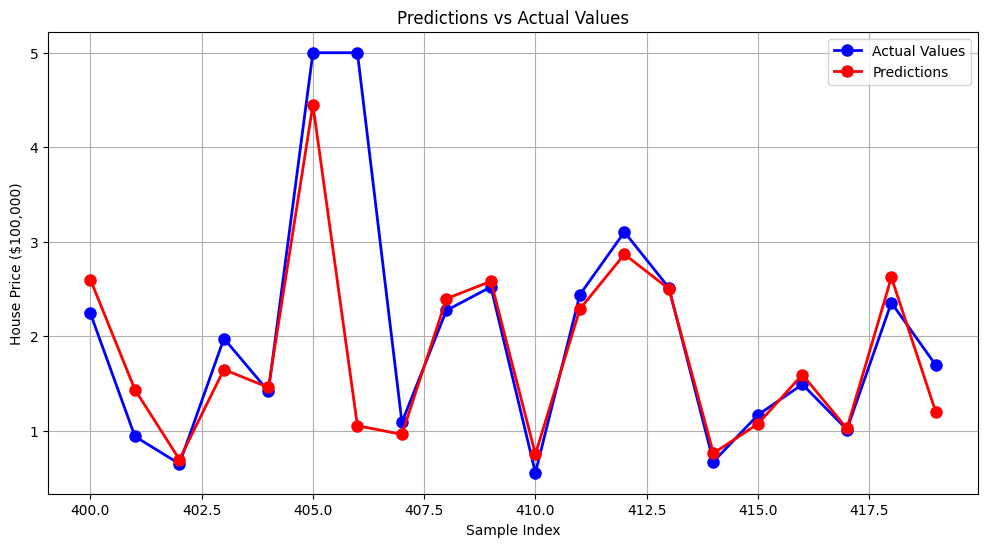

In [71]:
sample_indices = range(400, 420)
sample_actual = y_test[400:420]
sample_pred = model.predict(X_test_scaled[400:420])

plt.figure(figsize=(12, 6))
plt.plot(sample_indices, sample_actual, 'bo-', label='Actual Values', linewidth=2, markersize=8)  # مقدار واقعی
plt.plot(sample_indices, sample_pred, 'ro-', label='Predictions', linewidth=2, markersize=8)      # پیش‌بینی
plt.xlabel('Sample Index')                                    # شماره نمونه
plt.ylabel('House Price ($100,000)')                         # قیمت خانه (۱۰۰٬۰۰۰ دلار)
plt.title('Predictions vs Actual Values')                    # مقایسه پیش‌بینی با مقادیر واقعی
plt.legend()                                                 # راهنما
plt.grid(True)                                               # نمایش خطوط شبکه
plt.show()

### نمودارهای تحلیل خطا (پراکندگی و میله‌ای)

In [ ]:
actual = y_test[400:410]           # ۱۰ نمونه واقعی
predicted = pred[:10]              # ۱۰ پیش‌بینی
errors = np.abs(actual - predicted.flatten())  # محاسبه خطاها

# ایجاد دو نمودار کنار هم
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# نمودار اول: مقایسه پیش‌بینی با مقدار واقعی (Scatter Plot)
axes[0].scatter(actual, predicted, color='blue', s=100, alpha=0.7)
axes[0].plot([0, 5], [0, 5], 'r--', label='Perfect Prediction')  # خط ایده‌آل
axes[0].set_xlabel('Actual Values')      # مقدار واقعی
axes[0].set_ylabel('Predictions')        # مقدار پیش‌بینی
axes[0].set_title('Actual vs Predictions')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# نمودار دوم: نمایش خطای هر نمونه (Bar Chart)
axes[1].bar(range(1, 11), errors, color='orange', edgecolor='black')
axes[1].set_xlabel('Sample Number')      # شماره نمونه
axes[1].set_ylabel('Absolute Error')     # خطای مطلق
axes[1].set_title('Error per Sample')
axes[1].set_xticks(range(1, 11))
axes[1].axhline(y=np.mean(errors), color='red', linestyle='--', label=f'Mean Error: {np.mean(errors):.2f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()